## 2.2 양자 위상 추정 (Quantum Phase Estimation, QPE)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
# 유니터리 연산 정의 (여기서는 간단한 게이트 U 사용)
theta = 1/8
U = QuantumCircuit(1)

In [3]:
# U는 위상 게이트
U.p(2 * np.pi * theta, 0)  

In [4]:
from IPython.display import display, Math

print("위상 게이트 P(λ): 위상 게이트는 블로흐 구의 Z축을 중심으로 한 단일 큐비트 회전이다. 행렬 표현은 다음과 같다:")
# 위상 게이트의 행렬 표현 출력
display(Math(r'P(\lambda) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\lambda} \end{pmatrix}'))
print("이 경우 λ = π/4 이므로 행렬은 다음과 같이 된다:")
display(Math(r'P\left(\frac{\pi}{4}\right) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}'))

위상 게이트 P(λ): 위상 게이트는 블로흐 구의 Z축을 중심으로 한 단일 큐비트 회전이다. 행렬 표현은 다음과 같다:


<IPython.core.display.Math object>

이 경우 λ = π/4 이므로 행렬은 다음과 같이 된다:


<IPython.core.display.Math object>

In [5]:
# QPE에 쓸 큐비트 수
n = 3  # 계수 큐비트 수

# 양자 위상 추정 회로 생성
qc = QuantumCircuit(n + 1, n)

# 참고: 이 예제는 대상 큐비트(인덱스 n)를 |0⟩ 그대로 두므로 P 게이트의 고윳값 위상 0이 추정된다.
#       φ=1/8을 직접 확인하려면 대상 큐비트를 고유상태 |1⟩로 준비(qc.x(n))해야 한다. (이론 노트 2.2 참고)

In [6]:
# 계수 큐비트에 하다마드 게이트 적용
for qubit in range(n):  # 0부터 n-1까지의 각 큐비트에 하다마드 게이트 적용
    qc.h(qubit)

In [7]:
# 제어-U 게이트 적용
for qubit in range(n):  # 0부터 n-1까지의 각 큐비트에 제어-U 게이트 적용
    qc.append(U.to_gate().control(1), [qubit, n]) 

In [8]:
# 계수 큐비트에 역QFT 적용
def qft_dagger(circuit, n):
    """회로의 앞쪽 n개 큐비트에 역QFT 적용"""
    for qubit in range(n//2):
        circuit.swap(qubit, n-1-qubit)
    for j in range(n):
        for m in range(j):
            circuit.cp(-np.pi/float(2**(j-m)), m, j)
        circuit.h(j)

qft_dagger(qc, n)

In [9]:
# 계수 큐비트 측정
qc.measure(range(n), range(n))

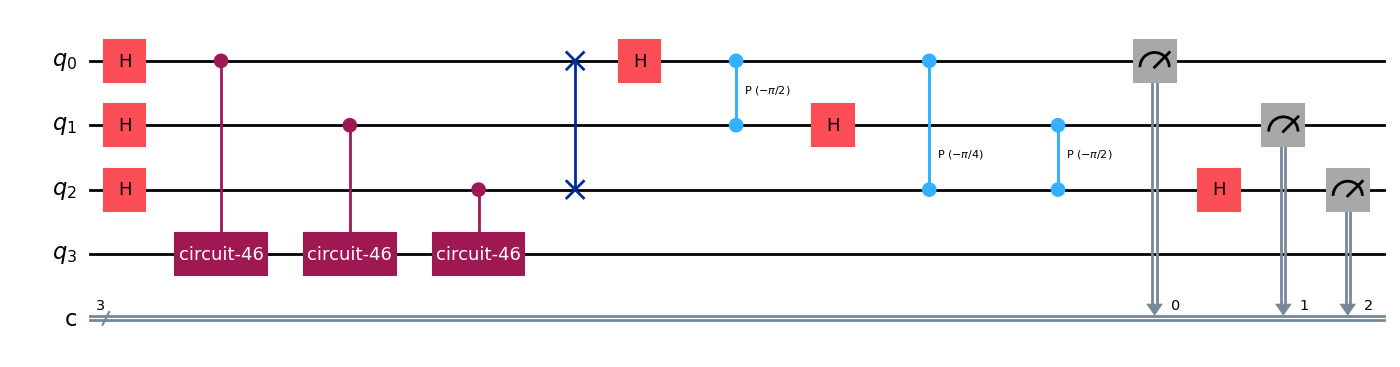

In [10]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [11]:
# 회로 시뮬레이션
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

In [12]:
# 시뮬레이터에서 회로 실행
result = simulator.run(compiled_circuit).result()

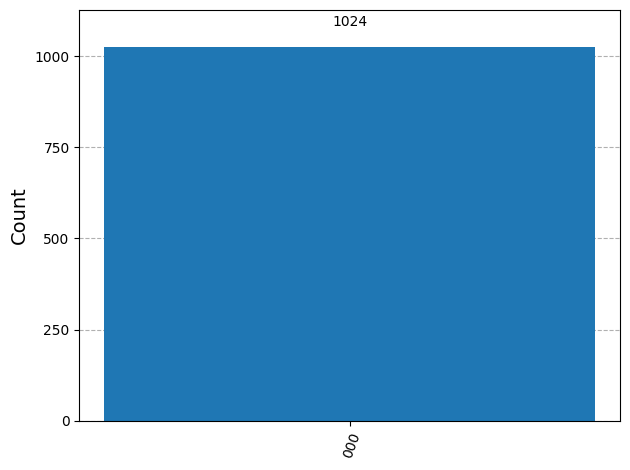

In [13]:
# 결과를 얻어 시각화
counts = result.get_counts(qc)
plot_histogram(counts)
plt.show()